In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("PS4_GamesSales.csv",encoding='latin-1')
df.head(2)

,Game,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global
0,Grand Theft Auto V,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09


In [6]:
print(df.describe())
print("Columns Name : - \n ",df.columns)

              Year  North America       Europe        Japan  Rest of World  \
count   825.000000    1034.000000  1034.000000  1034.000000    1034.000000   
mean   2015.966061       0.204613     0.248714     0.033636       0.089014   
std       1.298360       0.563471     0.785491     0.108344       0.249410   
min    2013.000000       0.000000     0.000000     0.000000       0.000000   
25%    2015.000000       0.000000     0.000000     0.000000       0.000000   
50%    2016.000000       0.020000     0.000000     0.000000       0.010000   
75%    2017.000000       0.120000     0.130000     0.030000       0.050000   
max    2020.000000       6.180000     9.710000     2.170000       3.020000   

            Global  
count  1034.000000  
mean      0.576054  
std       1.583534  
min       0.000000  
25%       0.000000  
50%       0.060000  
75%       0.357500  
max      19.390000  
Columns Name : - 
  Index(['Game', 'Year', 'Genre', 'Publisher', 'North America', 'Europe',
       'Japan', 

In [7]:
print(df.dtypes)

Game              object
Year             float64
Genre             object
Publisher         object
North America    float64
Europe           float64
Japan            float64
Rest of World    float64
Global           float64
dtype: object


In [9]:
# check null value...
print(df.isnull().sum())

Game               0
Year             209
Genre              0
Publisher        209
North America      0
Europe             0
Japan              0
Rest of World      0
Global             0
dtype: int64


In [10]:
print(df.size)

9306


In [11]:
df['Publisher'] = df['Publisher'].fillna("Unknown")

In [12]:
df['Year'] = df['Year'].fillna(2012)

In [13]:
# check null value...
print(df.isnull().sum())

Game             0
Year             0
Genre            0
Publisher        0
North America    0
Europe           0
Japan            0
Rest of World    0
Global           0
dtype: int64


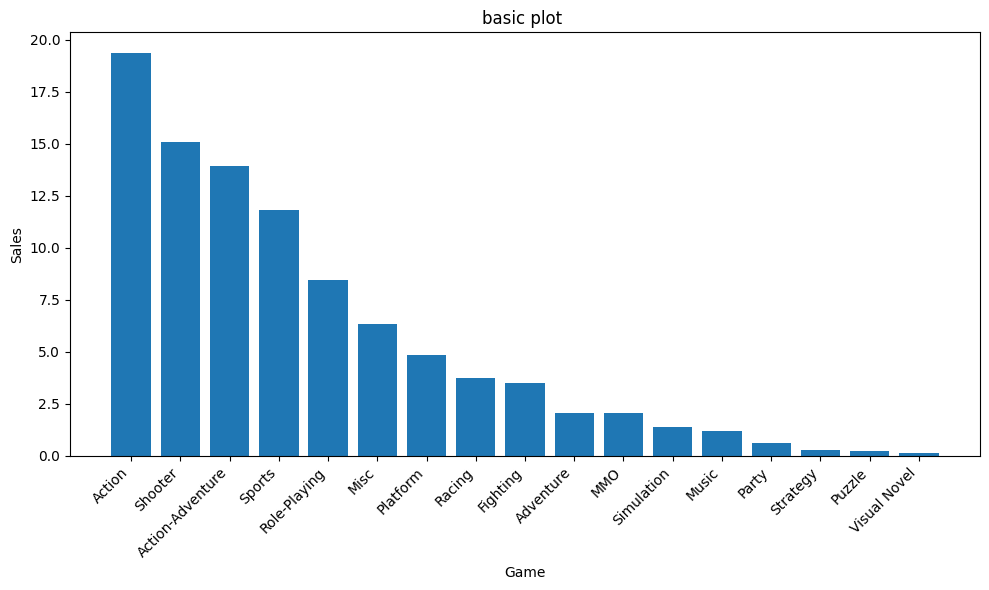

In [23]:
# Basic bar plot

plt.figure(figsize=(10,6))
plt.bar(df['Genre'],df['Global'])
plt.title("basic plot ")
plt.xlabel("Game")
plt.ylabel("Sales")
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.savefig("my_chart.png")
plt.show() 

Year
2012.0      0.22
2013.0     28.76
2014.0    115.85
2015.0    133.99
2016.0    135.72
2017.0    130.90
2018.0     50.20
2019.0      0.00
2020.0      0.00
Name: Global, dtype: float64


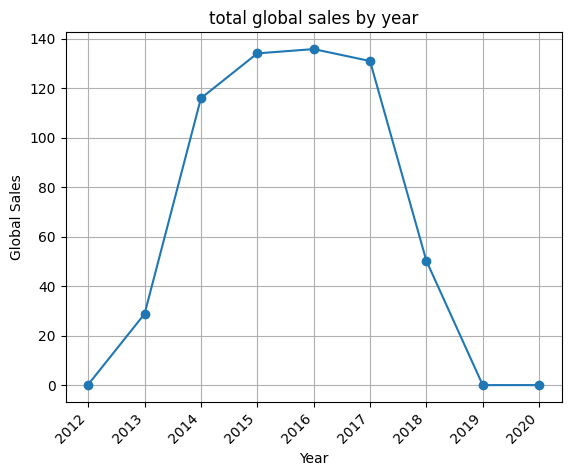

In [29]:
# basic line plot sales Trend over year

sales_by_year = df.groupby('Year')['Global'].sum().sort_index()
print(sales_by_year)
plt.Figure(figsize=(8,5))
plt.plot(sales_by_year.index,sales_by_year.values,marker='o')
plt.title("total global sales by year")
plt.xlabel("Year")
plt.ylabel("Global Sales")
plt.grid(True)
plt.xticks(rotation=45,ha='right')
plt.show()



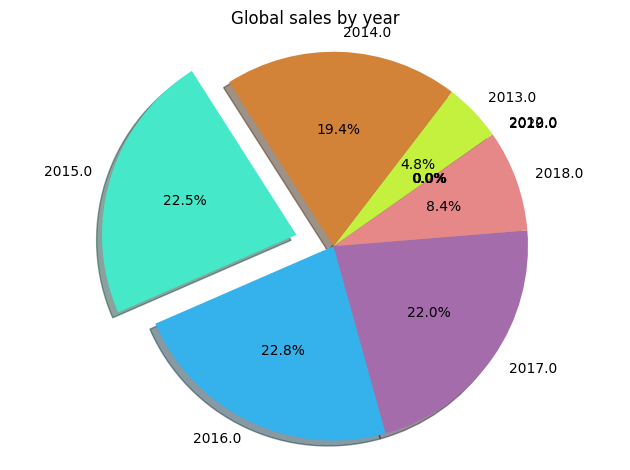

In [51]:
# basic pie chart sales genre

genre_sales = df.groupby('Genre')['Global'].sum()
#print(genre_sales)

explode = [0.2 if year == 2015 else 0 for year in sales_by_year.index]

colors_pie = ['#A86658',"#C4F03E","#D38338","#45E8C8","#35B1EB","#A46CAB","#E68888","#E1EDBE"]

plt.pie(sales_by_year,labels=sales_by_year.index,autopct='%1.1f%%',colors=colors_pie,startangle=35,shadow=True,explode=explode)
plt.title("Global sales by year")
plt.axis('equal')
plt.tight_layout()
plt.show()